# Atelier 2 — Apprentissage supervisé sur le CO2

L’objectif est de prédire la cible `co2_mixte` exprimée en g/km à partir de caractéristiques techniques de véhicule. Ce problème relève de la régression supervisée car la variable cible est quantitative et continue. Le but n’est pas d’optimiser à tout prix une métrique, mais de vérifier si les variables retenues permettent une bonne généralisation sans fuite entre variantes de la même famille.

## 1. Chargement et préparation du dataset

La donnée est déjà nettoyée. Nous gardons uniquement les variables utiles et nous normalisons les noms de colonnes pour éviter les erreurs d’accès et les fuites de logique. Les colonnes texte sont aussi nettoyées pour garder des familles homogènes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, GroupShuffleSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

rnd_state = 42
df = pd.read_csv("../donnees_nettoyees/vehicules_analyse_conso_co2.csv", sep=";", encoding="utf-8-sig")
df.columns = df.columns.str.strip().str.lower()
for col in ["cnit", "lib_mrq_doss", "lib_mod_doss", "energ", "hybride", "typ_boite_nb_rapp"]:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

df["famille"] = df["lib_mrq_doss"].fillna("").astype(str) + " | " + df["lib_mod_doss"].fillna("").astype(str)
print("Dataset chargé :", df.shape)
display(df.head(3))

Dataset chargé : (20824, 13)


,cnit,lib_mrq_doss,lib_mod_doss,energ,hybride,typ_boite_nb_rapp,puiss_admin,puiss_max,masse_ordma_min,masse_ordma_max,conso_mixte,co2_mixte,famille
0,M10ALFVP000G340,ALFA ROMEO,159,ES,non,M 6,12,147.0,1505,1505,7.8,182.0,ALFA ROMEO | 159
1,M10ALFVP000H341,ALFA ROMEO,159,ES,non,M 6,12,147.0,1555,1555,8.0,186.0,ALFA ROMEO | 159
2,M10ALFVP000E302,ALFA ROMEO,159,GO,non,M 6,7,100.0,1565,1565,5.1,134.0,ALFA ROMEO | 159


## 2. Variable cible, variables explicatives et risque de fuite

La cible à prédire est `co2_mixte` exprimée en g/km. Les variables autorisées ici sont techniques et disponibles au moment de la spécification du véhicule : puissance, masse, énergie, hybridation et transmission.

À exclure :
- `conso_mixte` car elle est quasi directement liée à la cible et introduit de la fuite ;
- `cnit` car il s’agit d’un identifiant ;
- les variables de même type ne servant pas à l’interprétation métier.

La colonne `lib_mrq_doss` + `lib_mod_doss` est utilisée uniquement pour constituer le groupe familial, pas comme feature de prédiction.

In [2]:
target = "co2_mixte"
features = [
    "puiss_admin",
    "puiss_max",
    "masse_ordma_min",
    "energ",
    "hybride",
    "typ_boite_nb_rapp",
]
assert target in df.columns
assert not set(["conso_mixte", "cnit"]).intersection(set(features))
assert set(features).issubset(set(df.columns))

X = df[features].copy()
y = df[target].copy()
groups = df["famille"]
print("Features retenues :", features)
print("Target :", target)

Features retenues : ['puiss_admin', 'puiss_max', 'masse_ordma_min', 'energ', 'hybride', 'typ_boite_nb_rapp']
Target : co2_mixte


## 3. Diagnostic du split familial

Un split aléatoire simple sur-estime souvent les performances, car des variantes proches d’une même famille peuvent être réparties entre le train et le test. Cela crée une fuite logique. Le diagnostic suivant décrit le comportement du jeu de validation et le risque de domination par quelques familles.

In [3]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=rnd_state)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()
groups_train = groups.iloc[train_idx].copy()
groups_test = groups.iloc[test_idx].copy()

print("Taille train :", X_train.shape)
print("Taille test :", X_test.shape)
print("Nombre de familles train :", groups_train.nunique())
print("Nombre de familles test :", groups_test.nunique())
print("Intersection train/test :", len(set(groups_train.unique()) & set(groups_test.unique())))
print("\nTop familles dans le test :")
print(groups_test.value_counts().head(10).to_string())
print("\nMoyenne CO2 train :", round(y_train.mean(), 2), "; écart-type :", round(y_train.std(), 2))
print("Moyenne CO2 test :", round(y_test.mean(), 2), "; écart-type :", round(y_test.std(), 2))


Taille train : (16004, 6)
Taille test : (4820, 6)
Nombre de familles train : 355
Nombre de familles test : 89
Intersection train/test : 0

Top familles dans le test :
famille
MERCEDES BENZ | SPRINTER      2697
BMW | SERIE 3                  223
VOLKSWAGEN | CRAFTER           220
MERCEDES BENZ | CLASSE GLA     176
BMW | SERIE X                  152
BMW | SERIE 2                  141
BMW | SERIE 5                  132
BMW | SERIE 6                   74
CITROEN | C4 PICASSO            60
VOLKSWAGEN | GOLF               57

Moyenne CO2 train : 147.63 ; écart-type : 43.26
Moyenne CO2 test : 177.67 ; écart-type : 39.39


**Interprétation.** Le test contient 89 familles et aucune famille n’est commune avec l’entraînement, ce qui respecte la séparation familiale. Il reste toutefois très concentré : `MERCEDES BENZ | SPRINTER` représente 2 697 lignes du test. La moyenne de CO2 est de 177,67 dans le test contre 147,63 dans l’entraînement, soit un écart de 30,04 g/km. Le test n’est donc pas représentatif de la moyenne d’entraînement ; un score unique doit être interprété avec prudence et complété par une validation groupée répétée.

## 4. Préprocesseur et pipeline

Le prétraitement est réalisé dans un `Pipeline` avec un `ColumnTransformer` pour garder la même logique de transformation pour tous les modèles. Les variables numériques sont imputées puis standardisées, tandis que les variables catégorielles sont codées via OneHot avec gestion des catégories inconnues.

In [4]:
numeric_features = ["puiss_admin", "puiss_max", "masse_ordma_min"]
categorical_features = ["energ", "hybride", "typ_boite_nb_rapp"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)
print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['puiss_admin', 'puiss_max',
                                  'masse_ordma_min']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['energ', 'hybride', 'typ_boite_nb_rapp'])])


## 5. Baseline et modèles

La baseline est un `DummyRegressor` à la moyenne, que l’on compare à des modèles plus structurés : régression linéaire, arbre de décision, Random Forest et KNN. Cela permet d’évaluer si l’apprentissage exploite réellement les relations entre les variables techniques et le CO2.

Validation groupée répétée :


,r2_mean,r2_std,rmse_mean,rmse_std,mae_mean,mae_std
model,,,,,,
Baseline_mean,-0.1676,0.2941,46.3583,8.1415,34.4289,8.0434
LinearRegression,0.8499,0.0452,16.6097,3.6233,11.2801,2.4469
DecisionTree,0.5816,0.3595,26.0992,8.6320,17.8993,5.2902
RandomForest,0.7588,0.1980,19.6741,6.5889,13.3185,4.2888
KNN,0.8054,0.1105,17.9715,3.1361,12.3654,2.2557


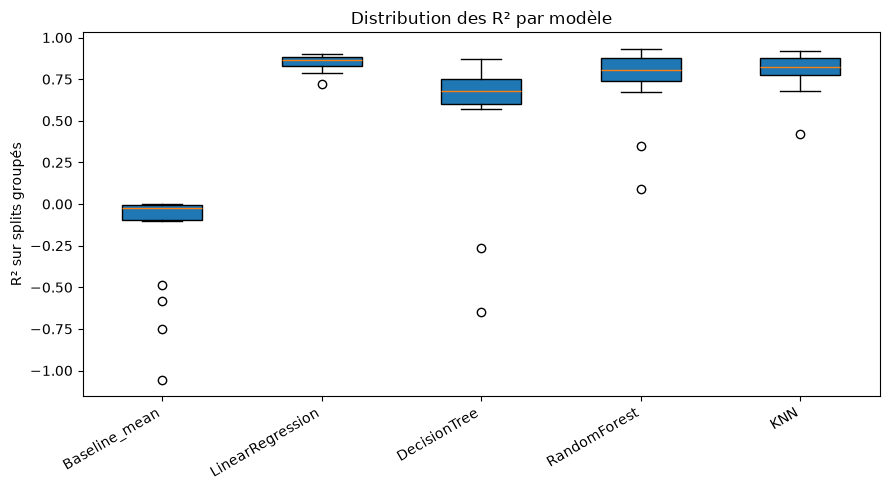

In [5]:
def metric_dict(y_true, y_pred):
    return {
        "r2": r2_score(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
    }

models = {
    "Baseline_mean": DummyRegressor(strategy="mean"),
    "LinearRegression": LinearRegression(),
    "DecisionTree": DecisionTreeRegressor(max_depth=6, random_state=rnd_state),
    "RandomForest": RandomForestRegressor(n_estimators=300, random_state=rnd_state, n_jobs=-1),
    "KNN": KNeighborsRegressor(n_neighbors=7),
}

cv = GroupShuffleSplit(n_splits=20, test_size=0.2, random_state=rnd_state)
rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        groups=groups,
        scoring={
            "r2": "r2",
            "rmse": "neg_root_mean_squared_error",
            "mae": "neg_mean_absolute_error",
        },
        n_jobs=1,
    )
    rows.append({
        "model": name,
        "r2_mean": scores["test_r2"].mean(),
        "r2_std": scores["test_r2"].std(),
        "rmse_mean": -scores["test_rmse"].mean(),
        "rmse_std": scores["test_rmse"].std(),
        "mae_mean": -scores["test_mae"].mean(),
        "mae_std": scores["test_mae"].std(),
    })

cv_df = pd.DataFrame(rows).set_index("model")
print("Validation groupée répétée :")
display(cv_df.round(4))

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, model) in enumerate(models.items(), start=1):
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    scores = cross_validate(
        pipe, X, y, cv=cv, groups=groups, scoring={"r2": "r2"}, n_jobs=1
    )["test_r2"]
    ax.boxplot(scores, positions=[i], patch_artist=True, widths=0.5)
ax.set_xticks(range(1, len(models) + 1))
ax.set_xticklabels(list(models), rotation=30, ha="right")
ax.set_ylabel("R² sur splits groupés")
ax.set_title("Distribution des R² par modèle")
plt.tight_layout()
plt.show()

**Interprétation.** Sur la validation groupée répétée, la régression linéaire est la meilleure sur le jeu complet (R² moyen 0,8499, écart-type 0,0452, RMSE 16,61, MAE 11,28). Le KNN suit avec un R² de 0,8054, tandis que le Random Forest atteint 0,7588 avec une dispersion plus forte (écart-type 0,1980). La comparaison repose donc sur plusieurs groupes et non sur un simple split ; la stabilité est aussi importante que le score moyen.

## 6. Sensibilité aux familles surreprésentées

On compare maintenant le jeu complet à un jeu plafonné à 50 variantes par famille. Cela permet de vérifier si les performances sont robustes ou si elles dépendent d’une petite poignée de familles très présentes.

In [6]:
def cap_families(df, max_per_family=50, random_state=42):
    rng = np.random.RandomState(random_state)
    sampled = []
    for fam, fam_df in df.groupby("famille"):
        sample = fam_df.sample(n=min(len(fam_df), max_per_family), random_state=rng.randint(0, 10_000))
        sampled.append(sample)
    return pd.concat(sampled, axis=0)

df_cap = cap_families(df, max_per_family=50, random_state=rnd_state)
X_cap = df_cap[features].copy()
y_cap = df_cap[target].copy()
groups_cap = df_cap["famille"]
cv_cap = GroupShuffleSplit(n_splits=20, test_size=0.2, random_state=rnd_state)
cap_rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])
    scores = cross_validate(pipe, X_cap, y_cap, cv=cv_cap, groups=groups_cap, scoring={"r2": "r2"}, n_jobs=1)
    cap_rows.append({
        "model": name,
        "r2_mean": scores["test_r2"].mean(),
        "r2_std": scores["test_r2"].std(),
    })
cap_df = pd.DataFrame(cap_rows).set_index("model")
print("Jeu plafonné à 50 par famille :")
display(cap_df.round(4))

comparison = cv_df[["r2_mean", "r2_std"]].join(cap_df.rename(columns={"r2_mean": "r2_mean_cap", "r2_std": "r2_std_cap"}))
print("\nComparaison complet / plafonné :")
display(comparison.round(4))

Jeu plafonné à 50 par famille :


,r2_mean,r2_std
model,,
Baseline_mean,-0.0169,0.0261
LinearRegression,0.8699,0.0228
DecisionTree,0.7865,0.0678
RandomForest,0.8819,0.0404
KNN,0.8647,0.0525



Comparaison complet / plafonné :


,r2_mean,r2_std,r2_mean_cap,r2_std_cap
model,,,,
Baseline_mean,-0.1676,0.2941,-0.0169,0.0261
LinearRegression,0.8499,0.0452,0.8699,0.0228
DecisionTree,0.5816,0.3595,0.7865,0.0678
RandomForest,0.7588,0.1980,0.8819,0.0404
KNN,0.8054,0.1105,0.8647,0.0525


**Interprétation.** Le plafonnement modifie le classement : le Random Forest devient meilleur (R² 0,8819) devant la régression linéaire (0,8699), alors qu’il était moins bon sur le jeu complet. Son écart-type reste toutefois plus élevé que celui de la régression linéaire (0,0404 contre 0,0228). Les conclusions du jeu complet dépendent donc en partie de la surreprésentation familiale ; le plafonnement apporte un contrôle de robustesse, sans prouver que l’une des deux distributions représente mieux un usage réel.

## 7. Ablation des variables

On compare plusieurs jeux de variables sur la même validation groupée répétée pour mesurer la contribution relative de chaque variable et la dépendance éventuelle à `puiss_admin` et au groupe énergétique.

In [7]:
ablation_sets = {
    "toutes_variables": features,
    "sans_puiss_admin": [c for c in features if c != "puiss_admin"],
    "sans_masse_ordma_min": [c for c in features if c != "masse_ordma_min"],
    "sans_energ": [c for c in features if c != "energ"],
    "puiss_admin_hybride": ["puiss_admin", "hybride"],
}

def build_preprocessor_for(feature_set):
    num_cols = [c for c in feature_set if c in ["puiss_admin", "puiss_max", "masse_ordma_min"]]
    cat_cols = [c for c in feature_set if c in ["energ", "hybride", "typ_boite_nb_rapp"]]
    return ColumnTransformer(
        transformers=[
            ("num", Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_cols),
            ("cat", Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), cat_cols),
        ]
    )

rows = []
for label, feature_set in ablation_sets.items():
    for model_name in ["LinearRegression", "RandomForest"]:
        X_sel = df[feature_set].copy()
        y_sel = df[target].copy()
        groups_sel = df["famille"]
        pipe = Pipeline(steps=[("preprocessor", build_preprocessor_for(feature_set)), ("model", models[model_name])])
        scores = cross_validate(pipe, X_sel, y_sel, cv=cv, groups=groups_sel, scoring={"r2": "r2"}, n_jobs=1)
        rows.append({
            "jeu": label,
            "modele": model_name,
            "r2_mean": scores["test_r2"].mean(),
            "r2_std": scores["test_r2"].std(),
        })

ablation_df = pd.DataFrame(rows).pivot_table(index="jeu", columns="modele", values="r2_mean")
print("Ablation des variables :")
display(ablation_df.round(4))
print("\nDétail complet :")
display(pd.DataFrame(rows).round(4))

Ablation des variables :


modele,LinearRegression,RandomForest
jeu,,
puiss_admin_hybride,0.4497,0.4627
sans_energ,0.7888,0.7425
sans_masse_ordma_min,0.5149,0.8650
sans_puiss_admin,0.7934,0.6663
toutes_variables,0.8499,0.7588



Détail complet :


,jeu,modele,r2_mean,r2_std
0,toutes_variables,LinearRegression,0.8499,0.0452
1,toutes_variables,RandomForest,0.7588,0.1980
2,sans_puiss_admin,LinearRegression,0.7934,0.0647
3,sans_puiss_admin,RandomForest,0.6663,0.2466
4,sans_masse_ordma_min,LinearRegression,0.5149,0.3917
5,sans_masse_ordma_min,RandomForest,0.8650,0.0594
6,sans_energ,LinearRegression,0.7888,0.0493
7,sans_energ,RandomForest,0.7425,0.1842
8,puiss_admin_hybride,LinearRegression,0.4497,0.4722
9,puiss_admin_hybride,RandomForest,0.4627,0.3931


**Interprétation.** Pour la régression linéaire, retirer `puiss_admin` fait passer le R² de 0,8499 à 0,7934 ; retirer `masse_ordma_min` le fait descendre à 0,5149, et ne garder que puissance administrative et hybridation à 0,4497. La masse apporte donc ici un signal important, tandis que les variables énergétiques complètent l’information. Pour le Random Forest, le retrait de `masse_ordma_min` donne 0,8650, supérieur au jeu complet (0,7588), ce qui montre que l’importance dépend du modèle et de la validation ; il ne faut pas conclure à une causalité à partir de cette ablation seule.

## 8. Interprétation des variables

On regarde maintenant les relations entre variables et la façon dont le modèle les ordonne. Les coefficients linéaires et l’importance des variables ne sont pas directement comparables, mais ils sont utiles pour questionner la structure apprise par le modèle.

In [8]:
corr_vars = df[["puiss_admin", "puiss_max", "masse_ordma_min"]].copy()
print("Matrice de corrélation des variables techniques :")
display(corr_vars.corr().round(4))

lin_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", LinearRegression())])
lin_pipe.fit(X_train, y_train)
feature_names = lin_pipe.named_steps["preprocessor"].get_feature_names_out()
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coef": lin_pipe.named_steps["model"].coef_,
}).sort_values("coef", key=lambda s: s.abs(), ascending=False)
print("\nCoefficients linéaires :")
display(coef_df.head(10).round(4))

rf_pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", RandomForestRegressor(n_estimators=300, random_state=rnd_state, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)
imp = pd.DataFrame({
    "feature": rf_pipe.named_steps["preprocessor"].get_feature_names_out(),
    "importance": rf_pipe.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)
print("\nImportance native du Random Forest :")
display(imp.head(10).round(4))

perm = permutation_importance(rf_pipe, X_test, y_test, n_repeats=5, random_state=rnd_state, n_jobs=-1)
perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_perm": perm.importances_mean,
}).sort_values("importance_perm", ascending=False)
print("\nImportance par permutation :")
display(perm_df.head(10).round(4))

Matrice de corrélation des variables techniques :


,puiss_admin,puiss_max,masse_ordma_min
puiss_admin,1.0000,0.9853,0.2343
puiss_max,0.9853,1.0000,0.2138
masse_ordma_min,0.2343,0.2138,1.0000



Coefficients linéaires :


,feature,coef
0,num__puiss_admin,65.1366
10,cat__energ_GL,-62.9689
4,cat__energ_EH,46.6560
1,num__puiss_max,-43.7230
3,cat__energ_EE,-42.2077
15,cat__hybride_non,32.6772
16,cat__hybride_oui,-32.6772
28,cat__typ_boite_nb_rapp_M 7,29.5175
7,cat__energ_ES/GP,26.0925
9,cat__energ_GH,25.8434



Importance native du Random Forest :


,feature,importance
0,num__puiss_admin,0.6912
2,num__masse_ordma_min,0.1696
1,num__puiss_max,0.0291
20,cat__typ_boite_nb_rapp_A 7,0.0254
5,cat__energ_ES,0.0246
3,cat__energ_EE,0.0131
15,cat__hybride_non,0.0112
16,cat__hybride_oui,0.0111
19,cat__typ_boite_nb_rapp_A 6,0.0077
13,cat__energ_GO,0.0035



Importance par permutation :


,feature,importance_perm
2,masse_ordma_min,1.4260
0,puiss_admin,0.8237
1,puiss_max,0.1221
3,energ,0.1061
5,typ_boite_nb_rapp,0.0523
4,hybride,0.0121


**Avertissement** — Les coefficients linéaires doivent être lus avec précaution car les variables techniques sont fortement corrélées entre elles, notamment `puiss_admin`, `puiss_max` et `masse_ordma_min`. Les colonnes OneHot de `hybride` ont été créées avec gestion des catégories inconnues pour éviter les écarts de codage.

Il n’y a pas ici de preuve de causalité : ce que l’on observe est un diagnostic de dépendance et de structure d’information, pas une explication causaliste du phénomène.

**Interprétation.** Le Random Forest attribue son importance native surtout à `puiss_admin` (0,6912) puis à `masse_ordma_min` (0,1696), mais l’importance par permutation du pipeline place `masse_ordma_min` en tête (1,4260), devant `puiss_admin` (0,8237). Cette différence montre que les variables corrélées se répartissent différemment selon la méthode ; `puiss_admin` et `puiss_max` sont d’ailleurs très corrélées. Les coefficients et importances décrivent une dépendance prédictive, pas des effets causaux.

## 9. Erreurs par énergie et par famille

Il est utile de regarder où le modèle échoue le plus : certaines énergies ou certaines familles peuvent concentrer les erreurs les plus fortes. Cela donne un signal métier plus riche que le seul score global.

In [9]:
best_name = "LinearRegression"
pipe = Pipeline(steps=[("preprocessor", preprocessor), ("model", models[best_name])])
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
err = pd.DataFrame({
    "y_true": y_test.values,
    "y_pred": pred,
    "abs_err": np.abs(y_test.values - pred),
    "energ": X_test["energ"].values,
    "famille": groups_test.values,
})
print("Erreur absolue moyenne par énergie :")
print(err.groupby("energ")["abs_err"].mean().sort_values(ascending=False).head(10).round(2).to_string())
print("\nErreur absolue moyenne par famille :")
print(err.groupby("famille")["abs_err"].mean().sort_values(ascending=False).head(10).round(2).to_string())

Erreur absolue moyenne par énergie :
energ
ES/GN    38.12
ES/GP    36.93
GP/ES    27.04
GH       19.99
GN       19.70
GO       13.95
ES       13.78
EH       10.68
GN/ES     7.51
EE        5.52

Erreur absolue moyenne par famille :
famille
AUDI | R8 COUPE                         84.67
INFINITI | QX50                         68.37
INFINITI | QX70                         65.94
MASERATI | GRANCABRIO MC                60.90
ROLLS ROYCE | PHANTOM DROPHEAD COUPE    53.62
LADA | 4X4                              50.92
NISSAN | MURANO                         50.87
PORSCHE | BOXSTER S                     49.34
AUDI | RS 6 AVANT                       47.42
DANGEL | SCUDO 4x4                      32.89


**Interprétation.** Les erreurs sont particulièrement élevées pour les énergies `ES/GN` (38,12 g/km) et `ES/GP` (36,93 g/km), mais ces catégories peuvent être rares. Par famille, les plus fortes erreurs concernent notamment `AUDI | R8 COUPE` (84,67), `INFINITI | QX50` (68,37) et `INFINITI | QX70` (65,94). Ces écarts suggèrent un effet conjoint de la rareté et de profils techniques atypiques ; ils justifient un diagnostic par effectif avant toute conclusion métier.

## 10. Synthèse de la chaîne complète

Question métier : peut-on prédire le CO2 d’un véhicule à partir de ses caractéristiques techniques ?

- X : puissance, masse, énergie, hybridation, transmission.
- y : `co2_mixte` en g/km.
- split : train/test et validation groupée par famille pour contrôler la fuite entre variantes proches.
- prétraitement : imputation + standardisation + OneHot.
- baseline : `DummyRegressor(strategy='mean')`.
- modèles : régression linéaire, arbre de décision, RandomForest, KNN.
- métriques : R², RMSE, MAE.
- points de vigilance : familles surreprésentées, colinéarité technique, modèle à comparer sur validation groupée et non sur un split unique.
- interprétation : le modèle doit être compris comme une approximation robuste, pas comme une vérité causaliste.

**Interprétation.** La régression linéaire est le choix le plus stable sur le jeu complet : R² 0,8499 et écart-type 0,0452, avec RMSE 16,61 et MAE 11,28. Après plafonnement, le Random Forest obtient le meilleur R² (0,8819), mais la régression linéaire reste plus régulière (écart-type 0,0228 contre 0,0404). Pour un décideur, il faut donc présenter les deux analyses : le modèle retenu dépend de la population visée, des erreurs acceptables et de la robustesse recherchée. Les familles déséquilibrées, la colinéarité et l’absence de variables métier supplémentaires limitent la portée de la prédiction.